<a href="https://colab.research.google.com/github/tmq24/Digital-Image-Analysis-and-Processing/blob/main/edge_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request # Used to download the image
import gdown # Used to download the image
from scipy import ndimage


In [ ]:
# Download the image and save it locally
urllib.request.urlretrieve('https://github.com/opencv/opencv/raw/master/samples/data/lena.jpg', 'lena.jpg')
gdown.download('https://drive.google.com/uc?export=download&id=1uOTHYNATlBs-7I6zC6WsJSg2YFp13yDP', 'flower.jpg', quiet=False)

# Load the image
image = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
flower = cv2.imread('flower.jpg', cv2.IMREAD_GRAYSCALE)

Downloading...
From: https://drive.google.com/uc?export=download&id=1uOTHYNATlBs-7I6zC6WsJSg2YFp13yDP
To: /content/flower.jpg
100%|██████████| 25.2k/25.2k [00:00<00:00, 37.5MB/s]


# Edge detection

Edge detection includes a variety of mathematical methods that aim at identifying edges, defined as curves in a digital image at which the image brightness changes sharply or, more formally, has discontinuities. The same problem of finding discontinuities in one-dimensional signals is known as step detection and the problem of finding signal discontinuities over time is known as change detection. Edge detection is a fundamental tool in image processing, machine vision and computer vision, particularly in the areas of feature detection and feature extraction.

#  Using First Order Derivative Methods in Edge Detection

**Using defaut kernel**

Different gradient operators can be applied to estimate image gradients from the input image or a smoothed version of it. The simplest approach is to use central differences:

$
L_x(x, y) = -\frac{1}{2} L(x-1, y) + 0 \cdot L(x, y) + \frac{1}{2} L(x+1, y)
$

$
L_y(x, y) = -\frac{1}{2} L(x, y-1) + 0 \cdot L(x, y) + \frac{1}{2} L(x, y+1)
$


**1.Finite Difference Approximations**

**Formulas:**

$$
\frac{\partial I}{\partial x} \approx \frac{1}{2} \left( \left(I_{i+1,j+1} - I_{i,j+1}\right) + \left(I_{i+1,j} - I_{i,j}\right) \right)
$$

$$
\frac{\partial I}{\partial y} \approx \frac{1}{2} \left( \left(I_{i+1,j+1} - I_{i+1,j}\right) + \left(I_{i,j+1} - I_{i,j}\right) \right)
$$

### Illustration:

| $I_{i,j}$        | $I_{i+1,j}$          |
|-------------------|----------------------|
| $I_{i,j+1}$       | $I_{i+1,j+1}$        |

$\epsilon$: Spacing between grid points.


In [ ]:
kernel_defaut_x = np.array([[-1,1],
                            [-1,1]], dtype=np.float32)

kernel_defaut_y = np.array([[1, 1],
                          [-1,-1]], dtype=np.float32)

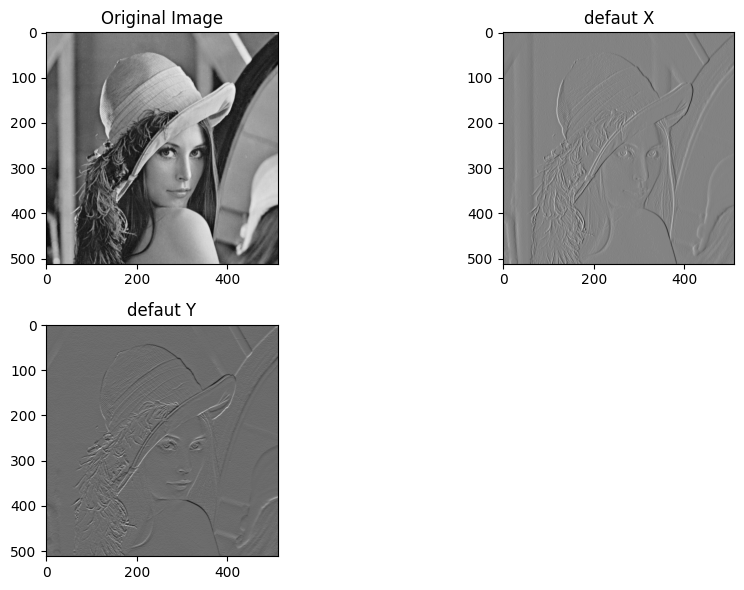

In [ ]:
# Apply defaut kernel operator in X and Y directions
defautx = cv2.filter2D(image, cv2.CV_64F, kernel_defaut_x)
defauty =  cv2.filter2D(image, cv2.CV_64F, kernel_defaut_y)

# Combine gradients
# kernel_defaut_combined = cv2.magnitude(kernel_defaut_x.astype(float), kernel_defaut_y.astype(float))

# Display results
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 2, 2), plt.imshow(defautx, cmap='gray'), plt.title('defaut X')
plt.subplot(2, 2, 3), plt.imshow(defauty, cmap='gray'), plt.title('defaut Y')
# plt.subplot(2, 2, 4), plt.imshow(kernel_defaut_combined, cmap='gray'), plt.title('defaut Combined')

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

**2. Sobel Operator**

The **Sobel operator** applies weighted smoothing to the image and uses two 3x3 convolution kernels for computing gradients in the horizontal (x) and vertical (y) directions.

**Kernels:**
$$
G_x =
\begin{bmatrix}
-1 & 0 & +1 \\
-2 & 0 & +2 \\
-1 & 0 & +1
\end{bmatrix}
\quad
G_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
+1 & +2 & +1
\end{bmatrix}
$$


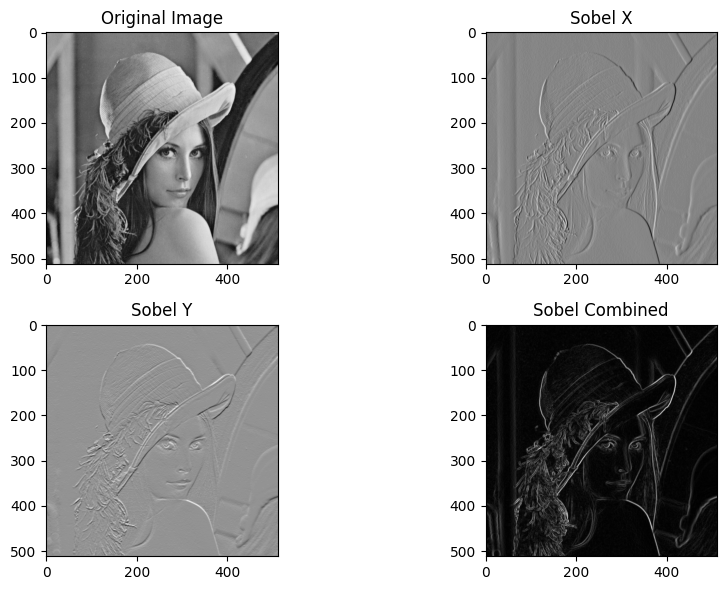

In [ ]:
# Apply Sobel operator in X and Y directions
sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# Combine gradients
sobel_combined = cv2.magnitude(sobelx, sobely)

# Display results
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 2, 2), plt.imshow(sobelx, cmap='gray'), plt.title('Sobel X')
plt.subplot(2, 2, 3), plt.imshow(sobely, cmap='gray'), plt.title('Sobel Y')
plt.subplot(2, 2, 4), plt.imshow(sobel_combined, cmap='gray'), plt.title('Sobel Combined')

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

**3.Robert Operator**

This gradient-based operator computes the sum of squares of the differences between diagonally adjacent pixels in an image through discrete differentiation. Then the gradient approximation is made. It uses the following 2 x 2 kernels or masks

**Kernels:**
$$
G_x =
\begin{bmatrix}
1 & 0  \\
0 & -1
\end{bmatrix}
\quad
G_y =
\begin{bmatrix}
0 & 1  \\
-1 & 0
\end{bmatrix}
$$

In [ ]:
kernel_Robert_x = np.array([[1,0],
                            [0,-1]], dtype=np.float32)

kernel_Robert_y = np.array([[0, 1],
                          [-1,0]], dtype=np.float32)

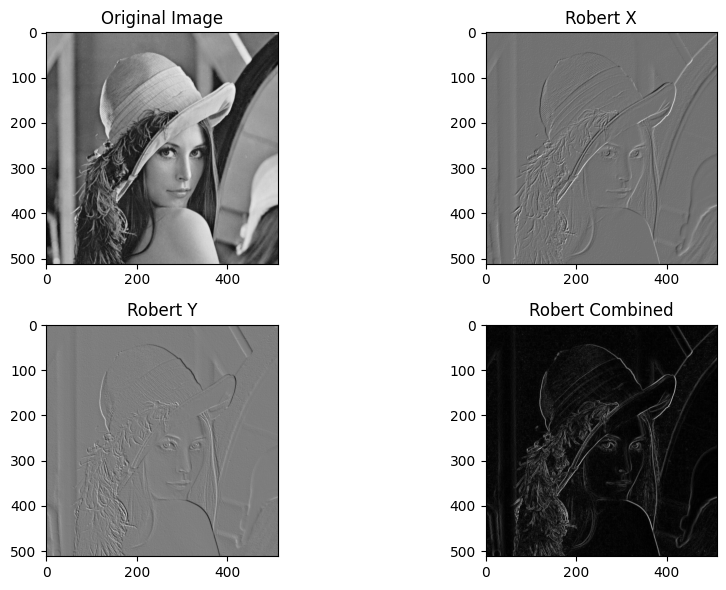

In [ ]:
# Apply Sobel operator in X and Y directions
Robertx = cv2.filter2D(image, cv2.CV_64F,kernel_Robert_x)
Roberty = cv2.filter2D(image, cv2.CV_64F,kernel_Robert_y)

# Combine gradients
Robert_combined = cv2.magnitude(Robertx, Roberty)

# Display results
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 2, 2), plt.imshow(Robertx, cmap='gray'), plt.title('Robert X')
plt.subplot(2, 2, 3), plt.imshow(Roberty, cmap='gray'), plt.title('Robert Y')
plt.subplot(2, 2, 4), plt.imshow(Robert_combined, cmap='gray'), plt.title('Robert Combined')

plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()

**Prewitt Operator**

The Prewitt operator is a simpler, faster method that applies uniform convolution kernels to calculate gradients in the x and y directions.

Kernels:
$$
G_x =
\begin{bmatrix}
-1 & 0 & +1 \\
-1 & 0 & +1 \\
-1 & 0 & +1
\end{bmatrix}
\quad
G_y =
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
+1 & +1 & +1
\end{bmatrix}
$$


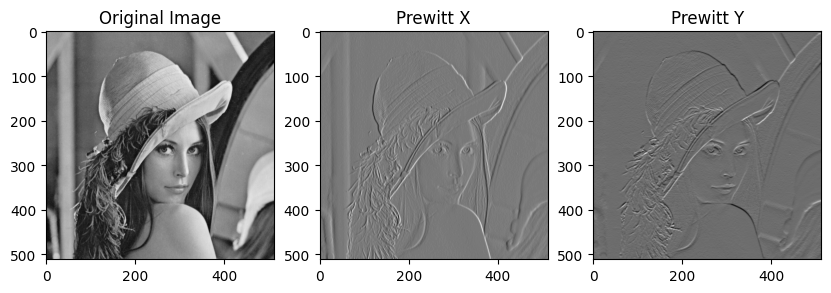

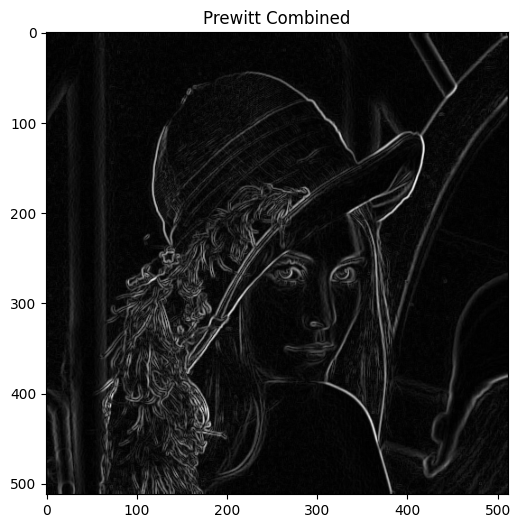

In [ ]:
prewittx_kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitty_kernel = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

prewittx = cv2.filter2D(image, cv2.CV_64F, prewittx_kernel)
prewitty = cv2.filter2D(image, cv2.CV_64F, prewitty_kernel)

prewitt_combined = cv2.magnitude(prewittx.astype(float), prewitty.astype(float))

plt.figure(figsize=(10,6))
plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 3, 2), plt.imshow(prewittx, cmap='gray'), plt.title('Prewitt X')
plt.subplot(1, 3, 3), plt.imshow(prewitty, cmap='gray'), plt.title('Prewitt Y')
plt.figure(figsize=(6,6))
plt.imshow(prewitt_combined, cmap='gray'), plt.title('Prewitt Combined')
plt.show()

#  Using Second Order Derivative Methods in Edge Detection

**Discrete Laplacian (∇²) Operator**

\begin{bmatrix}
I_{i-1, j+1} & I_{i, j+1} & I_{i+1, j+1} \\
I_{i-1, j} & I_{i, j} & I_{i+1, j} \\
I_{i-1, j-1} &I_{i, j-1} & I_{i+1, j-1}
\end{bmatrix}

Finite difference approximations:

$
\frac{\partial^2 I}{\partial x^2} \approx \frac{1}{\epsilon^2} \left( I_{i-1,j} - 2I_{i,j} + I_{i+1,j} \right)
$

$
\frac{\partial^2 I}{\partial y^2} \approx \frac{1}{\epsilon^2} \left( I_{i,j-1} - 2I_{i,j} + I_{i,j+1} \right)
$

$
\therefore \nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$

Convolution Mask:

$
\nabla^2 \approx \frac{1}{\epsilon^2}
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}
$
$
\quad \text{OR} \quad
\nabla^2 \approx \frac{1}{6\epsilon^2}
\begin{bmatrix}
1 & 4 & 1 \\
4 & -20 & 4 \\
1 & 4 & 1
\end{bmatrix} \quad \text{(More Accurate)}
$


In [ ]:
def apply_laplacian(img, kernel_size=(3, 3), scale=0):
    """
    Apply Gaussian blur and Laplacian edge detection to an image.

    Parameters:
        image (numpy.ndarray): The input image to process.
        kernel_size (tuple): The kernel size for the Gaussian blur. Default is (3, 3).
        scale (int): The standard deviation in the X direction for Gaussian blur. Default is 0.

    Returns:
        numpy.ndarray: The processed image after applying the Laplacian operator.
    """
    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(img, kernel_size, scale)

    # Apply the Laplacian operator to detect edges
    laplacian = cv2.Laplacian(blurred_image, cv2.CV_64F)

    # Convert the result to 8-bit format for visualization
    laplacian_abs = cv2.convertScaleAbs(laplacian)

    return laplacian_abs


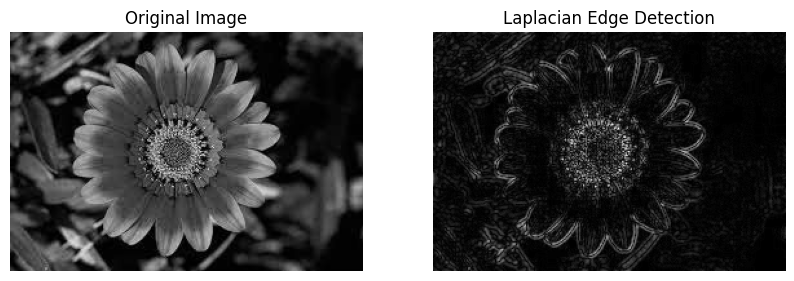

In [ ]:
laplacian_abs = apply_laplacian(flower)

# Display the result
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(flower, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Laplacian edge-detected image
plt.subplot(1, 2, 2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

plt.show()

**Canny edge detection**

The Canny edge detector is an edge detection operator that uses a multi-stage algorithm to detect a wide range of edges in images. It was developed by John F. Canny in 1986. Canny also produced a computational theory of edge detection explaining why the technique works. (Wikipedia)

The Canny edge detection algorithm is composed of 5 steps:

1. Noise reduction;
2. Gradient calculation;
3. Non-maximum suppression;
4. Double threshold;
5. Edge Tracking by Hysteresis.


In [ ]:
# Function to detect edges in an image using Canny edge detection
def detect_edges(image_path):
    # Read the image in grayscale mode
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    assert img is not None, "File could not be read, check with os.path.exists()"

    # Apply Canny edge detection algorithm to the image
    edges = cv2.Canny(img, 100, 200)

    # Return the processed image with edges detected
    return edges

In [ ]:
img_hysteresis = detect_edges("/content/flower.jpg")

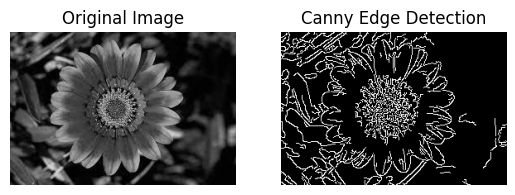

In [ ]:
# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(flower, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Canny edge-detected image
plt.subplot(1, 2, 2)
plt.imshow(img_hysteresis, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()

# Homework

**Theoretical Exercises:**

1. Compare the methods of first-order derivative and applied-order derivative in edge detection. What are the advantages and disadvantages of each method?
2. List the advantages and disadvantages of the kernels used in the first-order derivative method.
3. What are the advantages of the Canny method compared to the methods mentioned above?
4. What are the applications of edge detection?

**Practical Exercises:**

1. Choose an image from external sources and apply all the methods as instructed above.
2. Choose a noisy image, then detect the edges using all the methods.
3. From the noisy image in question 2, apply any denoising method, and then detect the edges using all the methods.
4. What conclusions can be drawn from the results in questions 2 and 3?



## Theoretical Exercises:

### **1. Compare the methods of first-order derivative and applied-order derivative in edge detection. What are the advantages and disadvantages of each method?**

| **Đặc điểm**                        | **First-order derivative**               | **Applied-order derivative**               |
|-------------------------------------|-----------------------------------------------|----------------------------------------------|
| **Mô tả**                           | Sử dụng đạo hàm bậc nhất để phát hiện cạnh qua sự thay đổi cường độ pixel. Các phép toán phổ biến như Sobel, Prewitt, Roberts. | Sử dụng đạo hàm bậc cao (đạo hàm bậc hai hoặc hơn) để tính toán độ cong và thay đổi của gradient để phát hiện cạnh. Ví dụ: Laplacian of Gaussian |
| **Ưu điểm**                         | - Dễ cài đặt và hiệu quả tính toán. <br> - Phù hợp với các cạnh có sự thay đổi cường độ rõ rệt. <br> - Có thể kết hợp với bộ lọc làm mịn để giảm nhiễu. | - Phát hiện cạnh chính xác hơn, có khả năng phát hiện các cạnh yếu và mờ nhạt. <br> - Robuster với nhiễu hơn so với phương pháp đạo hàm bậc nhất. <br> - Phát hiện được các cạnh nhỏ và tinh tế. |
| **Nhược điểm**                      | - Nhạy cảm với nhiễu, dễ bị ảnh hưởng bởi sự thay đổi nhỏ trong cường độ. <br> - Khó phát hiện các cạnh yếu hoặc có sự thay đổi cường độ từ từ. <br> - Độ chính xác thấp trong việc xác định vị trí cạnh. | - Tính toán phức tạp hơn so với đạo hàm bậc nhất. <br> - Có thể gây ra lỗi phát hiện cạnh do nhiễu hoặc các cạnh không hoàn hảo. <br> - Độ nhạy cảm cao với độ phân giải ảnh và cần điều chỉnh tham số kỹ lưỡng. |

### **2. List the advantages and disadvantages of the kernels used in the first-order derivative method.**

| **Bộ lọc**                         | **Ưu điểm**                                       | **Nhược điểm**                                    |
|------------------------------------|--------------------------------------------------|--------------------------------------------------|
| **Bộ lọc Sobel**                   | - Tính toán đơn giản và hiệu quả về thời gian. <br> - Phù hợp với cả cạnh theo chiều ngang và dọc. <br> - Giảm nhiễu tốt khi kết hợp với bộ lọc làm mịn. | - Nhạy cảm với nhiễu, hiệu quả kém với các ảnh nhiễu cao. <br> - Phát hiện kém các cạnh chéo (đối với các cạnh không phải theo chiều ngang hoặc dọc). |
| **Bộ lọc Prewitt**                 | - Hiệu suất tốt trong việc phát hiện các cạnh dọc và ngang. <br> - Toán tử tốt nhất để phát hiện hướng của hình ảnh. | - Độ lớn của hệ số là cố định và không thể thay đổi. <br> - Các điểm hướng chéo không phải lúc nào cũng được bảo toàn. |
| **Bộ lọc Roberts**                 | - Phát hiện các cạnh và hướng rất dễ dàng. <br> - Các điểm hướng chéo được bảo toàn. | - Nhạy cảm với nhiễu, đặc biệt trong các vùng tần số cao. <br> - Kích thước kernel nhỏ làm giảm hiệu quả với cạnh mờ. |

---


### **3. What are the advantages of the Canny method compared to the methods mentioned above?**

| **Đặc điểm**                      | **Phương pháp Đạo hàm bậc nhất (Sobel, Prewitt, Roberts)**   | **Phương pháp Đạo hàm bậc cao (LoG, DoG)**                 | **Phương pháp Canny**                                      |
|-----------------------------------|------------------------------------------------------------|------------------------------------------------------------|------------------------------------------------------------|
| **Độ chính xác**                  | Được sử dụng để phát hiện các cạnh rõ ràng, nhưng đôi khi không xác định được vị trí cạnh chính xác. | Phát hiện các cạnh yếu hơn nhưng có thể phát hiện các cạnh mờ nhạt. | Cung cấp độ chính xác cao, xác định vị trí cạnh chính xác đến mức subpixel. |
| **Khả năng loại bỏ nhiễu**        | Kém trong việc xử lý nhiễu, có thể tạo ra các cạnh giả.     | Phát hiện cạnh mượt mà hơn, nhưng có thể tạo ra lỗi do nhiễu. | Rất hiệu quả trong việc loại bỏ nhiễu nhờ vào bộ lọc Gaussian. |
| **Khả năng phát hiện các cạnh yếu**| Thường không phát hiện được các cạnh yếu.                  | Có thể phát hiện các cạnh yếu, nhưng đôi khi kết quả không chính xác. | Phát hiện tốt các cạnh yếu thông qua ngưỡng hai mức (hysteresis). |
| **Tính toán**                     | Nhanh chóng và đơn giản, tính toán ít tốn kém.              | Tính toán phức tạp hơn, tốn kém hơn so với bậc nhất.         | Tính toán phức tạp và tốn kém, đòi hỏi nhiều bước xử lý.   |
| **Cảm giác về độ mịn của cạnh**  | Cạnh thường thô, không mượt mà.                            | Cạnh mượt mà hơn, nhưng không chính xác bằng Canny.          | Cạnh rất mượt mà, liên tục và mảnh.                        |
| **Đặc tính linh hoạt**            | Không linh hoạt, không thể điều chỉnh ngưỡng để thay đổi kết quả. | Cũng không linh hoạt, phụ thuộc vào độ chính xác của tham số. | Rất linh hoạt với ngưỡng hai mức có thể điều chỉnh. |
| **Yêu cầu về tham số**            | Không yêu cầu điều chỉnh nhiều tham số.                      | Yêu cầu điều chỉnh tham số, đặc biệt là trong bộ lọc Gaussian. | Cần điều chỉnh ngưỡng hai mức và bộ lọc Gaussian cho hiệu quả tốt nhất. |



Phương pháp **Canny** thường được đánh giá cao hơn trong việc phát hiện cạnh vì nó kết hợp các lợi thế của cả phương pháp đạo hàm bậc nhất và bậc cao, đồng thời có khả năng phát hiện cạnh chính xác, mịn màng và loại bỏ nhiễu hiệu quả. Tuy nhiên, Canny yêu cầu tính toán phức tạp và phải điều chỉnh các tham số cẩn thận. Trong khi đó, các phương pháp đạo hàm bậc nhất và bậc cao có thể nhanh hơn và dễ cài đặt, nhưng thường thiếu chính xác và linh hoạt hơn so với Canny.

### **4. What are the applications of edge detection?**

**Edge detection** có vai trò then chốt trong các ứng dụng computer vision, machine learning hay AI. Kỹ thuật này được sử dụng như một bước tiền xử lý quan trọng trong các tác vụ nhận dạng đối tượng, giúp xác định rõ ràng ranh giới và hình dạng của vật thể trong ảnh. Trong các hệ thống học sâu, đặc biệt là Convolutional neural network, thông tin về cạnh từ các lớp đầu tiên đóng vai trò quan trọng, giúp mạng học được các đặc trưng cấp cao hơn như kết cấu và hình dạng. Các ứng dụng thực tế bao gồm hệ thống xe tự lái, nơi phát hiện cạnh giúp nhận diện làn đường, người đi bộ và các chướng ngại vật; hệ thống robot trong công nghiệp, hỗ trợ việc nắm bắt và điều hướng chính xác các đối tượng; và trong các ứng dụng thực tế tăng cường (AR), kỹ thuật này giúp định vị và theo dõi các điểm mốc trong môi trường thực. Nhờ khả năng trích xuất thông tin cấu trúc quan trọng từ ảnh, phát hiện cạnh tiếp tục là một công cụ cơ bản trong việc phát triển các hệ thống AI có khả năng hiểu và tương tác hiệu quả với thế giới thực.

# Practical Exercises:

In [ ]:
gdown.download('https://drive.google.com/uc?id=1Gt3EaVta3Ea6NQfsaAaI7QYFaf1c9n1Z', 'car.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?id=1RB291TIAsch03vRGkYJuDeCQ8gCDuoln', 'noisy.jpg', quiet=False)

# Load the image
car = cv2.imread('car.jpg', cv2.IMREAD_GRAYSCALE)
noisy = cv2.imread('noisy.jpg', cv2.IMREAD_GRAYSCALE)

Downloading...
From: https://drive.google.com/uc?id=1Gt3EaVta3Ea6NQfsaAaI7QYFaf1c9n1Z
To: /content/car.jpg
100%|██████████| 260k/260k [00:00<00:00, 69.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RB291TIAsch03vRGkYJuDeCQ8gCDuoln
To: /content/noisy.jpg
100%|██████████| 125k/125k [00:00<00:00, 50.2MB/s]


## 1. Choose an image from external sources and apply all the methods as instructed above.

In [ ]:
def comprehensive_edge_detection(image):
    """
    Thực hiện phát hiện cạnh bằng nhiều phương pháp khác nhau và hiển thị kết quả.

    Parameters:
        image: Ảnh đầu vào ở dạng grayscale

    Returns:
        Dictionary chứa tất cả các kết quả phát hiện cạnh
    """

    # 1. Default Method với kernel 2x2
    kernel_default_x = np.array([[-1, 1],
                                [-1, 1]], dtype=np.float32)
    kernel_default_y = np.array([[1, 1],
                                [-1, -1]], dtype=np.float32)

    # Áp dụng kernel mặc định
    default_x = cv2.filter2D(image, cv2.CV_64F, kernel_default_x)
    default_y = cv2.filter2D(image, cv2.CV_64F, kernel_default_y)
    default_combined = cv2.magnitude(default_x, default_y)

    # 2. Sobel Operator (3x3)
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)

    # 3. Roberts Operator (2x2)
    kernel_robert_x = np.array([[1, 0],
                               [0, -1]], dtype=np.float32)
    kernel_robert_y = np.array([[0, 1],
                               [-1, 0]], dtype=np.float32)

    robert_x = cv2.filter2D(image, cv2.CV_64F, kernel_robert_x)
    robert_y = cv2.filter2D(image, cv2.CV_64F, kernel_robert_y)
    robert_combined = cv2.magnitude(robert_x, robert_y)

    # 4. Prewitt Operator (3x3)
    prewitt_x = np.array([[1, 0, -1],
                          [1, 0, -1],
                          [1, 0, -1]], dtype=np.float32)
    prewitt_y = np.array([[1, 1, 1],
                          [0, 0, 0],
                          [-1, -1, -1]], dtype=np.float32)

    prewitt_x_result = cv2.filter2D(image, cv2.CV_64F, prewitt_x)
    prewitt_y_result = cv2.filter2D(image, cv2.CV_64F, prewitt_y)
    prewitt_combined = cv2.magnitude(prewitt_x_result, prewitt_y_result)

    # 5. Laplacian
    laplacian_abs = apply_laplacian(image)

    # 6. Canny
    canny = cv2.Canny(image, 100, 200)

    # Tạo dictionary chứa tất cả kết quả
    results = {
        'default': {
            'x': default_x,
            'y': default_y,
            'combined': default_combined
        },
        'sobel': {
            'x': sobel_x,
            'y': sobel_y,
            'combined': sobel_combined
        },
        'robert': {
            'x': robert_x,
            'y': robert_y,
            'combined': robert_combined
        },
        'prewitt': {
            'x': prewitt_x_result,
            'y': prewitt_y_result,
            'combined': prewitt_combined
        },
        'laplacian': laplacian_abs,
        'canny': canny
    }

    return results

In [ ]:
def display(image, results):
    """
    Hiển thị kết quả phát hiện cạnh từ các phương pháp khác nhau.

    Parameters:
        image: Ảnh gốc
        results: Dictionary chứa kết quả từ các phương pháp phát hiện cạnh
    """
    # 1. Hiển thị kết quả Default Method
    plt.figure(figsize=(10, 6))
    plt.suptitle('Default Method Results')
    plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(2, 2, 2), plt.imshow(results['default']['x'], cmap='gray'), plt.title('Default X')
    plt.subplot(2, 2, 3), plt.imshow(results['default']['y'], cmap='gray'), plt.title('Default Y')
    plt.subplot(2, 2, 4), plt.imshow(results['default']['combined'], cmap='gray'), plt.title('Default Combined')
    plt.tight_layout()
    plt.show()

    # 2. Hiển thị kết quả Sobel
    plt.figure(figsize=(10, 6))
    plt.suptitle('Sobel Operator Results')
    plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(2, 2, 2), plt.imshow(results['sobel']['x'], cmap='gray'), plt.title('Sobel X')
    plt.subplot(2, 2, 3), plt.imshow(results['sobel']['y'], cmap='gray'), plt.title('Sobel Y')
    plt.subplot(2, 2, 4), plt.imshow(results['sobel']['combined'], cmap='gray'), plt.title('Sobel Combined')
    plt.tight_layout()
    plt.show()

    # 3. Hiển thị kết quả Roberts
    plt.figure(figsize=(10, 6))
    plt.suptitle('Roberts Operator Results')
    plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(2, 2, 2), plt.imshow(results['robert']['x'], cmap='gray'), plt.title('Roberts X')
    plt.subplot(2, 2, 3), plt.imshow(results['robert']['y'], cmap='gray'), plt.title('Roberts Y')
    plt.subplot(2, 2, 4), plt.imshow(results['robert']['combined'], cmap='gray'), plt.title('Roberts Combined')
    plt.tight_layout()
    plt.show()

    # 4. Hiển thị kết quả Prewitt
    plt.figure(figsize=(10, 6))
    plt.suptitle('Prewitt Operator Results')
    plt.subplot(2, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(2, 2, 2), plt.imshow(results['prewitt']['x'], cmap='gray'), plt.title('Prewitt X')
    plt.subplot(2, 2, 3), plt.imshow(results['prewitt']['y'], cmap='gray'), plt.title('Prewitt Y')
    plt.subplot(2, 2, 4), plt.imshow(results['prewitt']['combined'], cmap='gray'), plt.title('Prewitt Combined')
    plt.tight_layout()
    plt.show()

    # 5. Hiển thị kết quả Laplacian và Canny
    plt.figure(figsize=(15, 5))
    plt.suptitle('Laplacian and Canny Results')
    plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(1, 3, 2), plt.imshow(results['laplacian'], cmap='gray'), plt.title('Laplacian')
    plt.subplot(1, 3, 3), plt.imshow(results['canny'], cmap='gray'), plt.title('Canny')
    plt.tight_layout()
    plt.show()

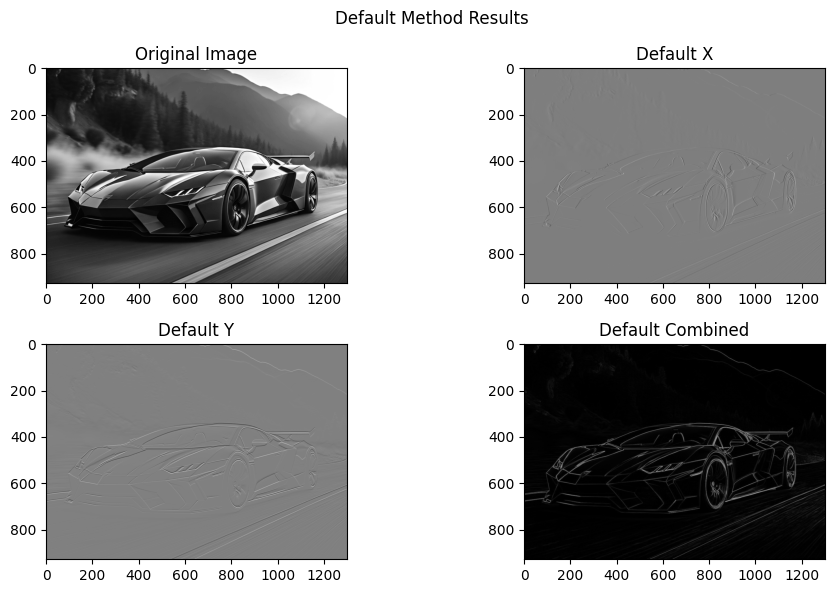

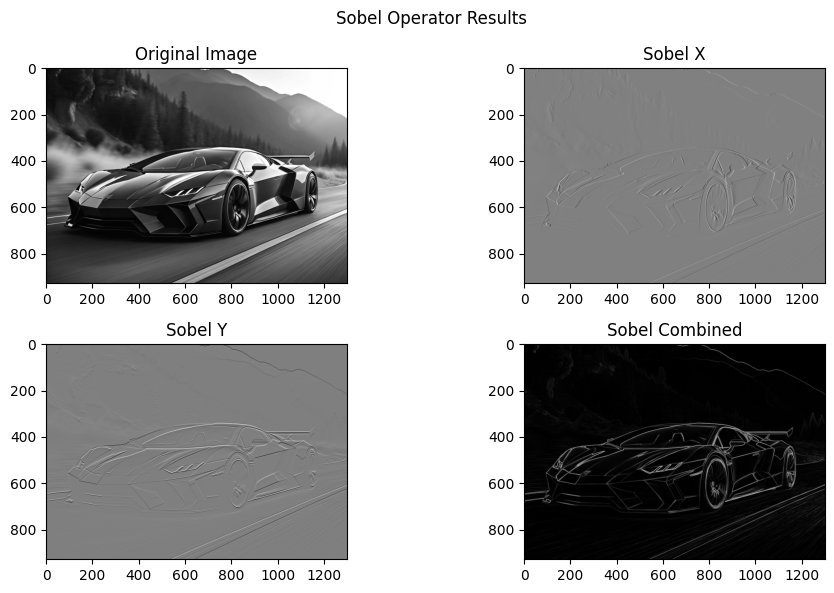

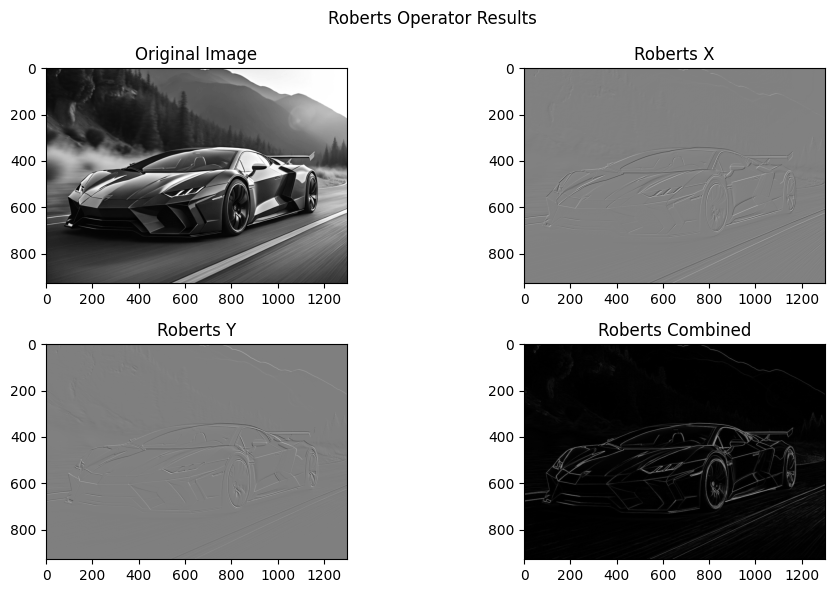

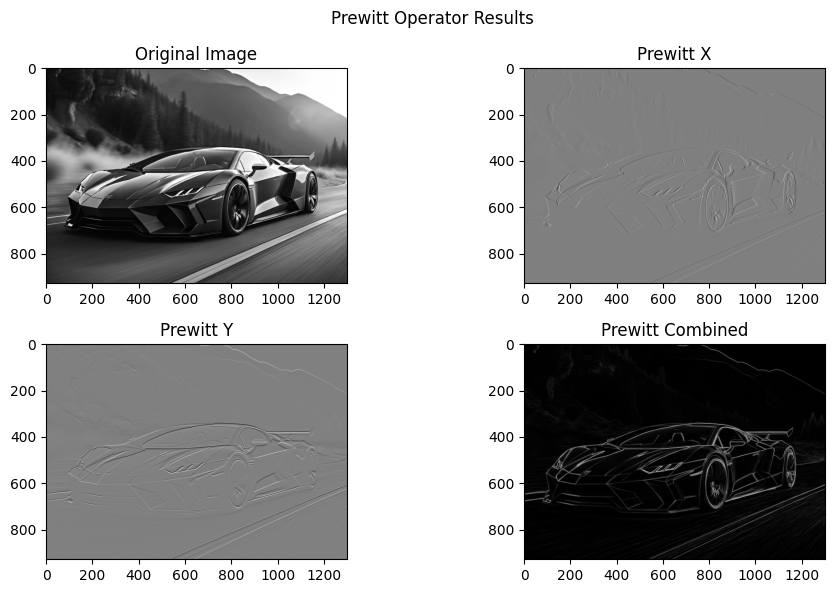

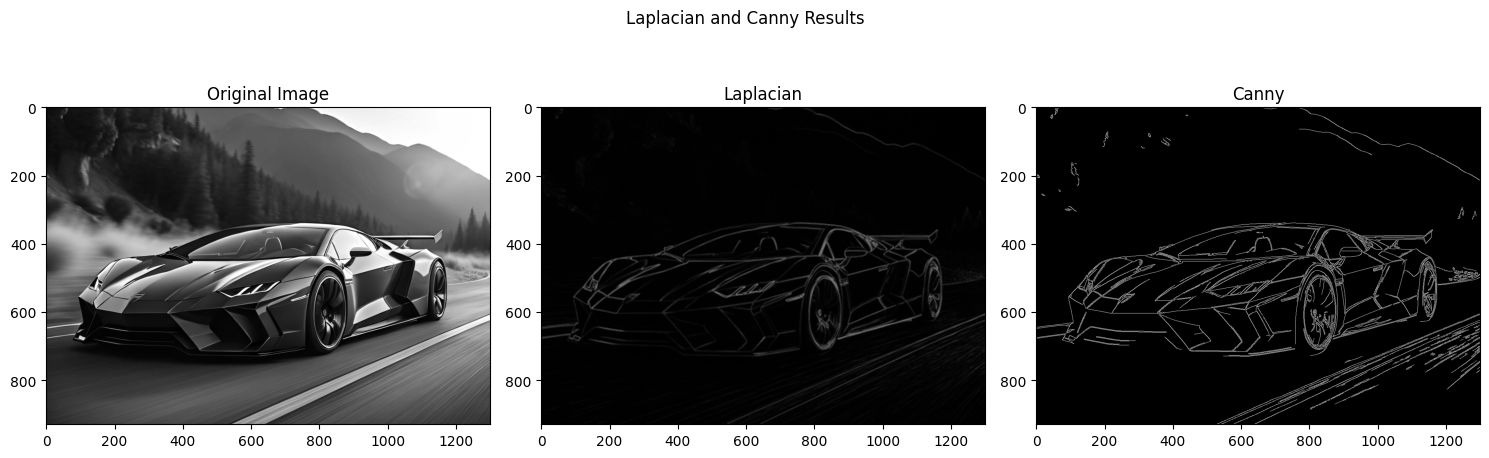

In [ ]:
results_car = comprehensive_edge_detection(car)
display(car, results_car)

## 2. Choose a noisy image, then detect the edges using all the methods.

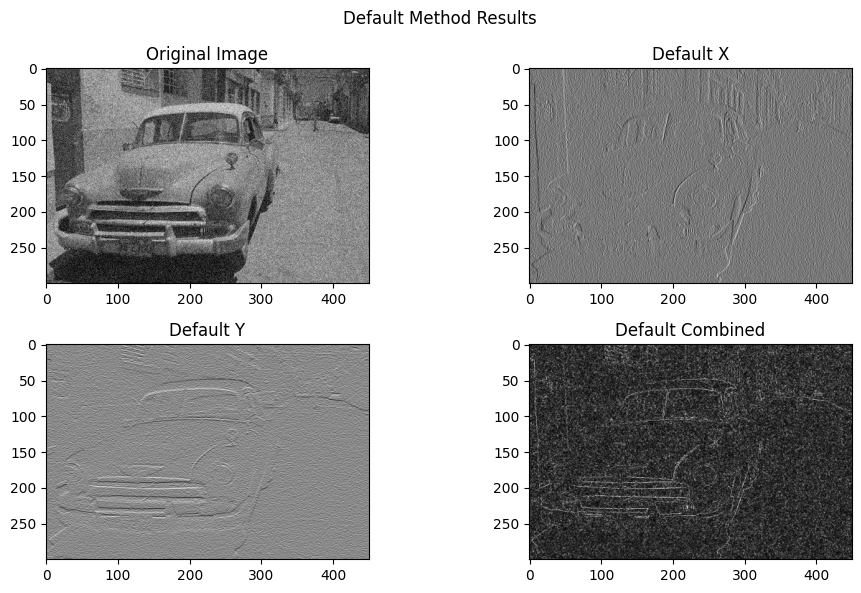

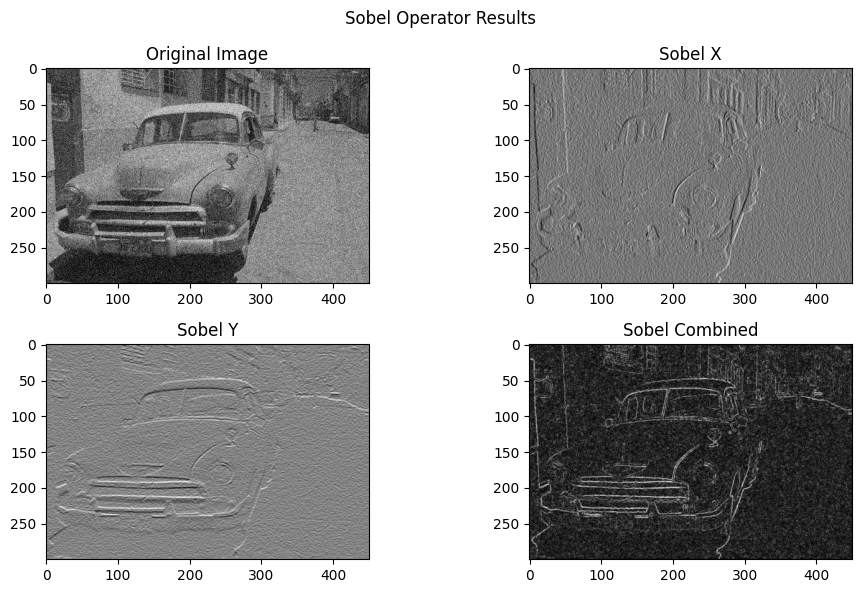

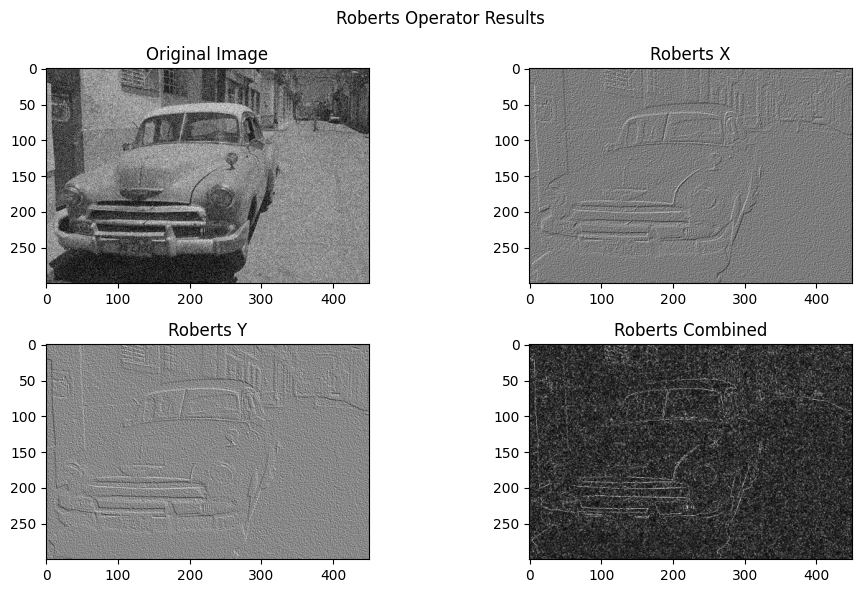

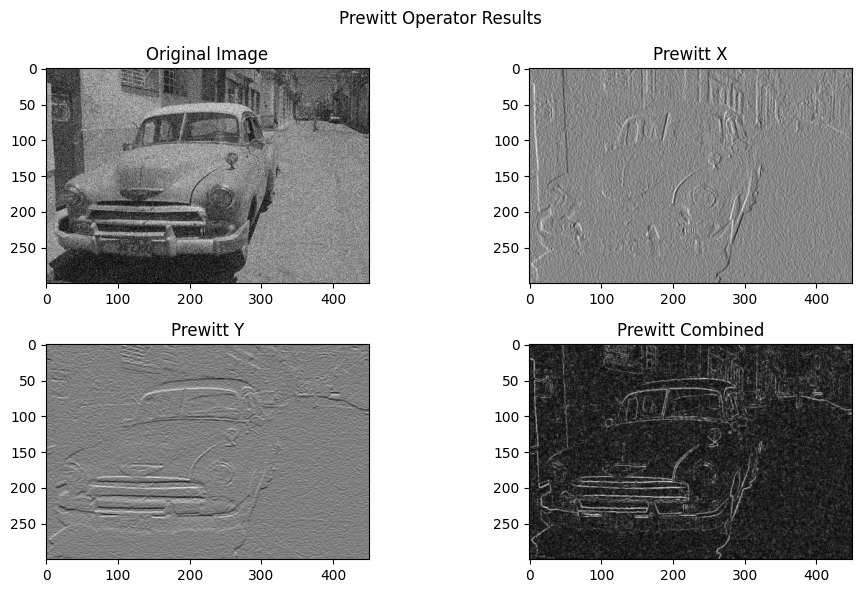

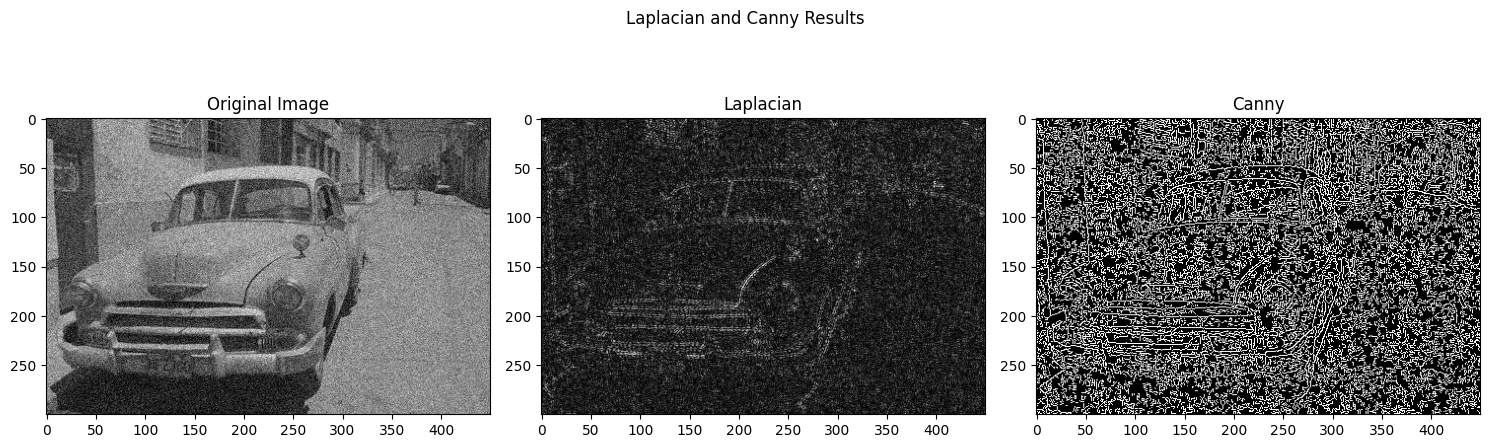

In [ ]:
results_noisy = comprehensive_edge_detection(noisy)
display(noisy, results_noisy)

## 3. From the noisy image in question 2, apply any denoising method, and then detect the edges using all the methods.

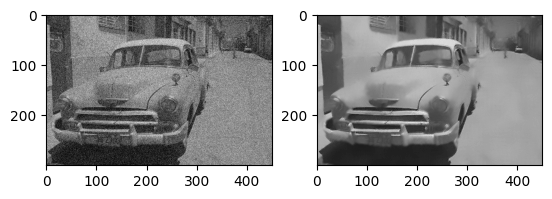

In [ ]:
denoised = cv2.fastNlMeansDenoising(noisy, None, 20, 7 ,21)

# Display the images
plt.subplot(121), plt.imshow(noisy, cmap='gray')
plt.subplot(122), plt.imshow(denoised, cmap='gray')
plt.show()

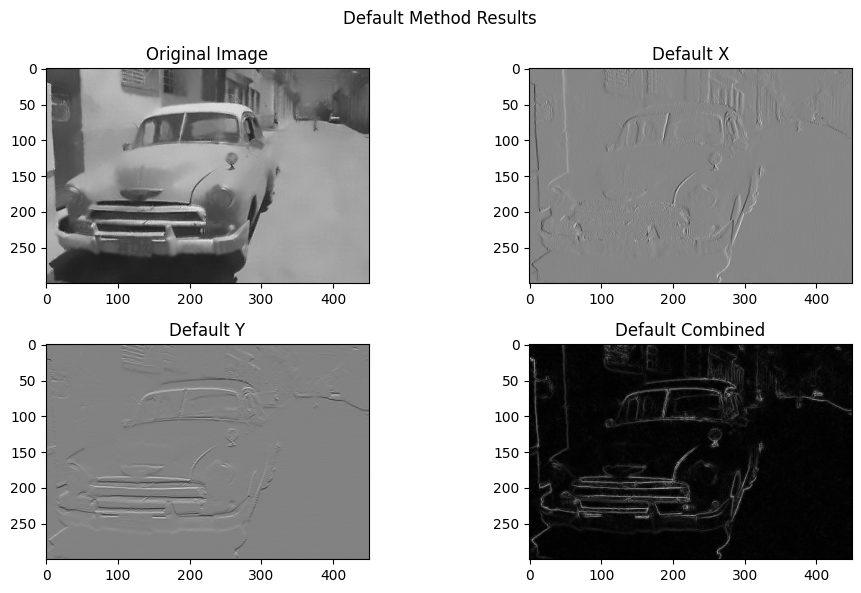

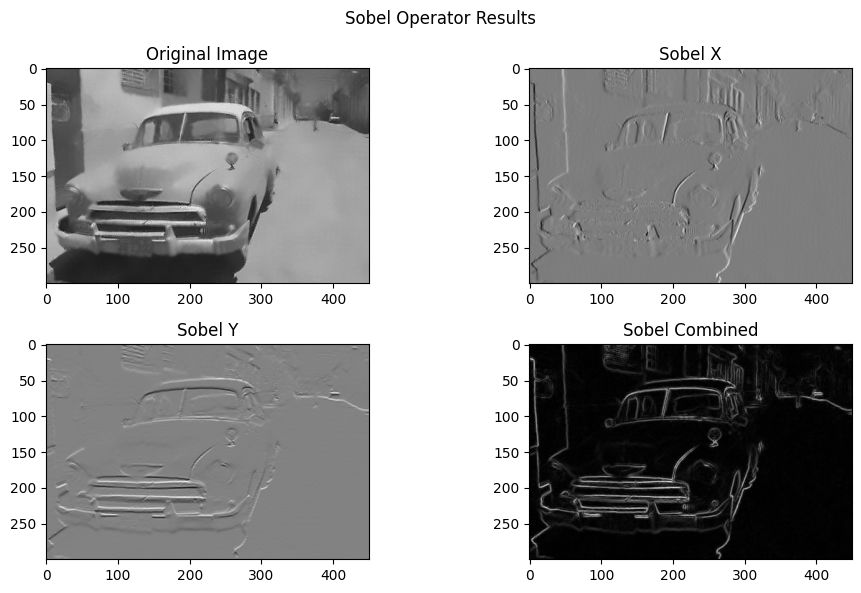

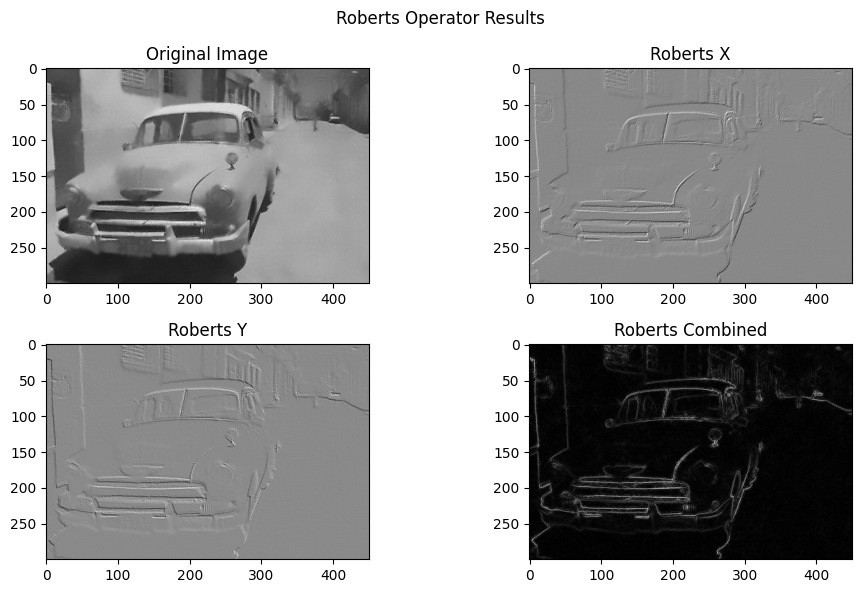

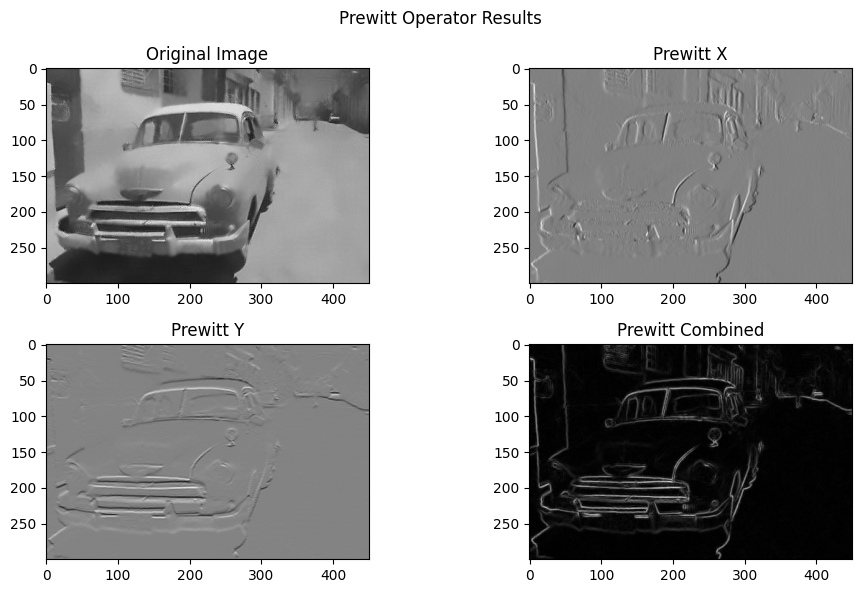

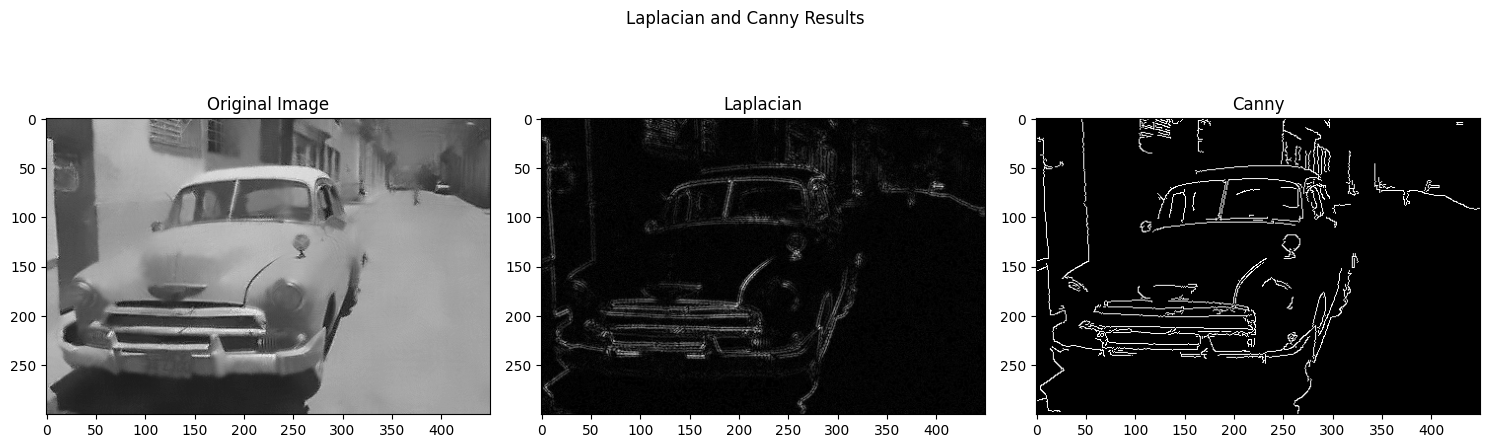

In [ ]:
results_denoised = comprehensive_edge_detection(denoised)
display(denoised, results_denoised)

## 4. What conclusions can be drawn from the results in questions 2 and 3?
**So sánh kết quả từng phương pháp:**

| Phương pháp | Trước khi khử nhiễu | Sau khi khử nhiễu |
|-------------|---------------------|-------------------|
| **Default** (2x2) | - Nhiễu cao trong cả hướng X và Y<br>- Gần như không thể phân biệt cạnh thật<br>- Gradient kết hợp bị nhiễu chi phối hoàn toàn | - Đường viền rõ ràng hơn<br>- Giảm đáng kể nhiễu nền<br>- Cấu trúc được thể hiện tốt hơn |
| **Sobel** (3x3)| - Bị ảnh hưởng bởi nhiễu nhưng tốt hơn Default<br>- Gradient vẫn bị nhiễu chi phối<br>- Có thể nhận ra một số cạnh chính | - Cạnh được định nghĩa rõ ràng<br>- Chuyển tiếp cạnh mượt mà<br>- Giữ được chi tiết quan trọng |
| **Roberts** (2x2) | - Cực kỳ nhạy cảm với nhiễu<br>- Mất hầu hết các cạnh chéo<br>- Kết quả gần như không sử dụng được | - Phát hiện cạnh cải thiện đáng kể<br>- Vẫn còn hơi thô do kernel nhỏ<br>- Phát hiện tốt các chi tiết nhỏ |
| **Prewitt** (3x3) | - Tương tự Sobel nhưng nhạy với nhiễu hơn<br>- Bị ảnh hưởng nhiều bởi nhiễu<br>- Khó phân biệt cạnh thật | - Kết quả tương đương Sobel<br>- Nhấn mạnh cạnh khác biệt<br>- Phát hiện tốt cạnh ngang và dọc |
| **Laplacian** | - Thông tin cạnh mờ<br>| - Phát hiện được các thay đổi đột ngột<br>- Hiển thị cả hai bên của cạnh<br>- Vẫn hơi nhạy với nhiễu còn sót |
| **Canny** |  - Kết quả không thể sử dụng<br>- Mất hoàn toàn thông tin cạnh | - Cạnh sạch và liên tục<br>- Ít cạnh giả<br>|

**Kết luận:**

1. **Xử lý nhiễu:**
- Các thuật toán Edge Detection rất nhạy cảm với nhiễu nên khử nhiễu là bước cực kỳ quan trọng để đạt được kết quả phát hiện cạnh có ý nghĩa.

2. **Ảnh hưởng của kích thước kernel:**
- Kernel lớn (3x3 như Sobel và Prewitt) xử lý nhiễu tốt hơn kernel nhỏ (2x2 như Roberts)

3. **Lựa chọn phương pháp:**
- Đối với ảnh nhiễu, nên ưu tiên các phương pháp có kernel lớn hơn
- Các phương pháp đa giai đoạn như Canny được hưởng lợi nhiều nhất từ việc khử nhiễu
- Các phương pháp đơn giản như Roberts trở nên khả thi hơn sau khi khử nhiễu hiệu quả

